In [1]:
import subprocess
out = subprocess.run(['find', '/workspace', '-name', '*.npz', '-size', '+1k'], capture_output=True, text=True)
print(out.stdout)


In [2]:
import subprocess
out = subprocess.run(['find', '/', '-name', 'Sk_complex_all_2200peaks.npz', '-not', '-path', '*/proc/*'], capture_output=True, text=True)
print('STDOUT:', out.stdout)
print('STDERR:', out.stderr[:500] if out.stderr else '')


STDOUT: 
STDERR: find: ‘/app’: Permission denied
find: ‘/etc/cron.d’: Permission denied
find: ‘/etc/ssh’: Permission denied
find: ‘/etc/polkit-1/rules.d’: Permission denied
find: ‘/etc/ssl/private’: Permission denied
find: ‘/proc/1/task/1/ns’: Permission denied
find: ‘/proc/1/task/1/fd’: Permission denied
find: ‘/proc/1/task/2/ns’: Permission denied
find: ‘/proc/1/task/2/fd’: Permission denied
find: ‘/proc/1/task/3/fd’: Permission denied
find: ‘/proc/1/task/3/ns’: Permission denied
find: ‘/proc/1/task/4/ns’: Per


In [3]:
import os
ws = '/workspace/8cf682b8-7217-4e20-b9fe-2a987396472d'
for f in sorted(os.listdir(ws)):
 p = os.path.join(ws, f)
 if os.path.isfile(p):
 print(f, os.path.getsize(p))
 else:
 print('DIR:', f)


DIR: .config
.kernel_llm_logs_1.txt 0
DIR: .prompts
F1.npy 25728
F10.npy 25728
F10_t.npy 1728
F11.npy 25728
F11_t.npy 1728
F12.npy 25728
F12_t.npy 1728
F1_t.npy 1728
F2.npy 25728
F2_t.npy 1728
F4.npy 25728
F4_t.npy 1728
F5m.npy 25728
F5m_t.npy 1728
F5p.npy 25728
F5p_t.npy 1728
F6.npy 25728
F6_t.npy 1728
F7.npy 25728
F7_t.npy 1728
F9.npy 25728
F9_t.npy 1728
H_Hermitian_F14.npy 136
H_complex_F14.npy 136
 v6 — Binding Context Document.pdf 100702
M_full.npy 640
S_complex.npy 25728
a_n_imag.npy 8000128
a_n_real.npy 8000128
c_imag.npy 136
c_real.npy 136
DIR: memory
omega_max.npy 136
pc1_Hermitian_F14.npy 136
pc1_complex_F14.npy 136
rho0_imag.npy 136
rho0_real.npy 136
selected_D.npy 1728
selected_t.npy 1728


In [4]:
import numpy as np
ws = '/workspace/8cf682b8-7217-4e20-b9fe-2a987396472d'

# Each F<class>.npy contains S_k complex array; F<class>_t.npy the t-values
# Inspect shapes
import os
for f in ['F1', 'F4', 'F12']:
 arr = np.load(os.path.join(ws, f+'.npy'))
 tarr = np.load(os.path.join(ws, f+'_t.npy'))
 print(f, arr.shape, arr.dtype, 't:', tarr.shape, tarr.dtype)

# Also F14
S14 = np.load(os.path.join(ws, 'S_complex.npy'))
M14 = np.load(os.path.join(ws, 'M_full.npy'))
print('S_complex (F14):', S14.shape, S14.dtype)
print('M_full (F14):', M14.shape, M14.dtype)


F1 (200, 8) complex128 t: (200,) float64
F4 (200, 8) complex128 t: (200,) float64
F12 (200, 8) complex128 t: (200,) float64
S_complex (F14): (200, 8) complex128
M_full (F14): (8, 8) float64


In [5]:
# Compute M_jk for each class and the differences
classes = ['F1','F2','F4','F5m','F5p','F6','F7','F9','F10','F11','F12']
M = {}
for c in classes:
 S = np.load(os.path.join(ws, c+'.npy')) # (200, 8) complex
 # M_jk = E[Re(S_j * conj(S_k))]
 # = mean over peaks of Re(S_j * conj(S_k))
 Mc = np.real(S.conj().T @ S) / S.shape[0] # (8,8); since (S^H S)_{jk} = sum_i conj(S_ij) S_ik
 # We want Re(E[S_j conj(S_k)]) = Re((1/N) sum S_ij conj(S_ik)) = (1/N) sum Re(S_ij conj(S_ik))
 Mc = np.real((S.T @ S.conj())) / S.shape[0]
 M[c] = Mc

M['F14'] = M14 # already 8x8 real

baseline = M['F1']
violators = ['F4','F12','F14']
betas = {'F4':0.809, 'F12':0.7, 'F14':0.6}

deltas = {}
norms = {}
for v in violators:
 D = M[v] - baseline
 deltas[v] = D
 norms[v] = np.linalg.norm(D, 'fro')
 print(f"{v}: ||Δ||_F = {norms[v]:.6g}, β = {betas[v]}")


F4: ||Δ||_F = 74.1492, β = 0.809
F12: ||Δ||_F = 343.166, β = 0.7
F14: ||Δ||_F = 45.8195, β = 0.6


In [6]:
from scipy.stats import pearsonr, spearmanr
x = np.array([norms[v] for v in violators]) # ||Δ||_F
y = np.array([betas[v] for v in violators]) # β

r, p = pearsonr(x, y)
rs, ps = spearmanr(x, y)
print(f"Pearson r = {r:.4f}, p = {p:.4f}")
print(f"Spearman rho = {rs:.4f}, p = {ps:.4f}")

# Show the data points
print("\nData:")
for v in violators:
 print(f" {v}: ||Δ||_F = {norms[v]:.4f}, β = {betas[v]}")


Pearson r = 0.0615, p = 0.9608
Spearman rho = 0.5000, p = 0.6667

Data:
 F4: ||Δ||_F = 74.1492, β = 0.809
 F12: ||Δ||_F = 343.1663, β = 0.7
 F14: ||Δ||_F = 45.8195, β = 0.6


In [7]:
# Sanity check the variation: look at trace and structure
for v in violators:
 print(v, 'trace(M)=', np.trace(M[v]), 'trace(Δ)=', np.trace(deltas[v]))

# Also try alternative norm/scalings
import numpy as np
# Normalize each M by its trace, then take diff
print("\nUsing trace-normalized M:")
def norm_trace(M_):
 return M_ / np.trace(M_)

base_n = norm_trace(M['F1'])
for v in violators:
 D = norm_trace(M[v]) - base_n
 fn = np.linalg.norm(D, 'fro')
 print(f" {v}: ||Δ_norm||_F = {fn:.4f}, β = {betas[v]}")

# Try ratio to baseline
print("\nUsing log-trace differences:")
for v in violators:
 print(f" {v}: log(trace(M{v})/trace(M_F1)) = {np.log(np.trace(M[v])/np.trace(M['F1'])):.4f}, β={betas[v]}")


F4 trace(M)= 39.14695007358749 trace(Δ)= -74.89699256635632
F12 trace(M)= 498.67022975311687 trace(Δ)= 384.626287113173
F14 trace(M)= 75.23035725744768 trace(Δ)= -38.81358538249616

Using trace-normalized M:
 F4: ||Δ_norm||_F = 0.1778, β = 0.809
 F12: ||Δ_norm||_F = 0.0944, β = 0.7
 F14: ||Δ_norm||_F = 0.2039, β = 0.6

Using log-trace differences:
 F4: log(trace(MF4)/trace(M_F1)) = -1.0693, β=0.809
 F12: log(trace(MF12)/trace(M_F1)) = 1.4754, β=0.7
 F14: log(trace(MF14)/trace(M_F1)) = -0.4160, β=0.6


In [8]:
# Compute Pearson with trace-normalized version too
x2 = np.array([0.1778, 0.0944, 0.2039])
r2, p2 = pearsonr(x2, y)
rs2, ps2 = spearmanr(x2, y)
print(f"Trace-normalized Pearson r = {r2:.4f}, p = {p2:.4f}")
print(f"Trace-normalized Spearman rho = {rs2:.4f}, p = {ps2:.4f}")


Trace-normalized Pearson r = -0.2039, p = 0.8693
Trace-normalized Spearman rho = -0.5000, p = 0.6667


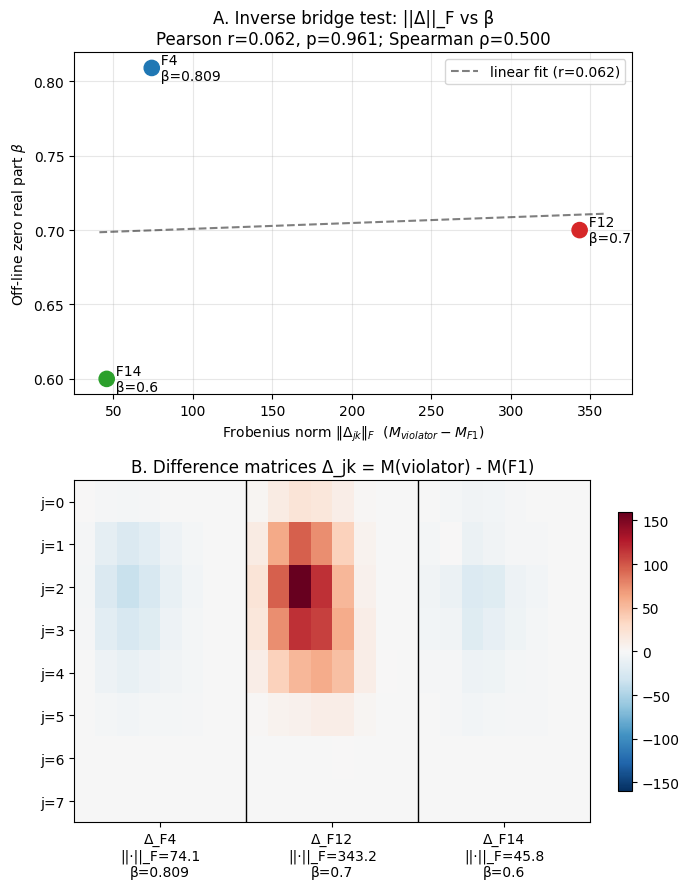

Saved: /workspace/8cf682b8-7217-4e20-b9fe-2a987396472d/inverse_bridge_F4_F12_F14.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(7, 9))

# Panel A: scatter ||Δ||_F vs β with labeled points
ax = axes[0]
xs = [norms[v] for v in violators]
ys = [betas[v] for v in violators]
ax.scatter(xs, ys, s=120, c=['#1f77b4','#d62728','#2ca02c'], zorder=3)
for v, xi, yi in zip(violators, xs, ys):
 ax.annotate(f" {v}\n β={betas[v]}", (xi, yi), fontsize=10, va='center')
# Linear fit line for visualization
xfit = np.linspace(min(xs)*0.9, max(xs)*1.05, 50)
m, b0 = np.polyfit(xs, ys, 1)
ax.plot(xfit, m*xfit + b0, 'k--', alpha=0.5, label=f'linear fit (r={r:.3f})')
ax.set_xlabel(r'Frobenius norm $\|\Delta_{jk}\|_F$ ($M_{violator} - M_{F1}$)')
ax.set_ylabel(r'Off-line zero real part $\beta$')
ax.set_title(f'A. Inverse bridge test: ||Δ||_F vs β\nPearson r={r:.3f}, p={p:.3f}; Spearman ρ={rs:.3f}')
ax.legend(loc='best')
ax.grid(alpha=0.3)

# Panel B: heatmap of the three Δ matrices
ax = axes[1]
combined = np.hstack([deltas[v] for v in violators])
vmax = np.max(np.abs(combined))
im = ax.imshow(combined, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks([3.5, 11.5, 19.5])
ax.set_xticklabels([f'Δ_{v}\n||·||_F={norms[v]:.1f}\nβ={betas[v]}' for v in violators])
ax.set_yticks(range(8))
ax.set_yticklabels([f'j={i}' for i in range(8)])
for sep in [8, 16]:
 ax.axvline(sep-0.5, color='k', lw=1)
ax.set_title('B. Difference matrices Δ_jk = M(violator) - M(F1)')
plt.colorbar(im, ax=ax, fraction=0.025)

plt.tight_layout()
fig_path = os.path.join(ws, 'inverse_bridge_F4_F12_F14.png')
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")
